# Recommendation Engine: Exploration and Modeling

This notebook develops a recommendation system from initial data exploration
to model construction. The first part focuses on understanding the interaction
data and its main characteristics, while the second part builds the
recommendation pipeline, including data splitting, baselines, and two
recommendation models.

## 1. Exploratory Data Analysis
This section of notebook explores the user-item interaction dataset before building the
recommendation models. The goal is to understand the structure, sparsity,
interaction distributions, rating behavior, and temporal activity of the data.

In [1]:
# Import required data analysis and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
from pathlib import Path

# Add the project root so modules inside src/ can be imported
sys.path.append(str(Path.cwd().parent))

In [3]:
# Import reusable project functions and variables
from src.data import load_data

In [4]:
# Load the interaction dataset using the reusable data-loading function
df = load_data()

# Display the first five rows to verify that the data loaded correctly
df.head()

,User_ID,Item_ID,Category,Rating,Timestamp,Price,Platform,Location
0,User_913,Item_52,Movies,2.0,2023-05-15,369.55,Web,Africa
1,User_3457,Item_66,Electronics,1.4,2023-08-19,255.15,Web,Africa
2,User_1629,Item_1467,Sports,2.7,2024-03-27,296.69,Web,Europe
3,User_3463,Item_697,Movies,1.6,2023-12-03,55.59,Tablet,North America
4,User_2941,Item_1736,Games,3.4,2023-02-06,366.22,Web,South America


### 1.1 User-Item Matrix Sparsity

Recommendation datasets are usually sparse because each user interacts with
only a small subset of all available items. Here, sparsity is measured using
unique user-item pairs rather than raw interaction rows.

In [5]:
# Count unique users and items
num_users = df["User_ID"].nunique()
num_items = df["Item_ID"].nunique()

# Keep only unique user-item pairs
unique_user_item_pairs = df[["User_ID", "Item_ID"]].drop_duplicates()

# Count observed user-item pairs
num_unique_pairs = unique_user_item_pairs.shape[0]

# Count repeated user-item interactions
num_repeated_interactions = len(df) - num_unique_pairs

# Count all possible user-item combinations
total_possible_unique_pairs = num_users * num_items

# Calculate density and sparsity
density = num_unique_pairs / total_possible_unique_pairs
sparsity = 1 - density

print("Number of users:", num_users)
print("Number of items:", num_items)
print("Unique user-item pairs:", num_unique_pairs)
print("Repeated user-item interactions:", num_repeated_interactions)
print("Density:", density)
print("Sparsity:", sparsity)

Number of users: 5000
Number of items: 2000
Unique user-item pairs: 148892
Repeated user-item interactions: 1108
Density: 0.0148892
Sparsity: 0.9851108


### Interpretation

Repeated user-item interactions are counted only once for sparsity because
they occupy the same cell in the user-item matrix. The user-item matrix has a density of approximately 1.49%, meaning that only a small fraction of all possible user-item pairs are observed. Equivalently, the matrix is approximately 98.51% sparse, so most users have interacted with only a small subset of the available items. This level of sparsity motivates the use of recommendation methods that can infer preferences for unseen items from limited observed interactions.

### 1.2 Interactions per User

This section examines how many interaction records each user has. The
distribution helps identify whether activity is concentrated among a small
number of highly active users or is relatively balanced across users.

In [6]:
# Count the number of interaction records for each user
interactions_per_user = df.groupby("User_ID").size()

# Display summary statistics
interactions_per_user.describe()

count    5000.000000
mean       30.000000
std         5.452371
min        14.000000
25%        26.000000
50%        30.000000
75%        34.000000
max        59.000000
dtype: float64

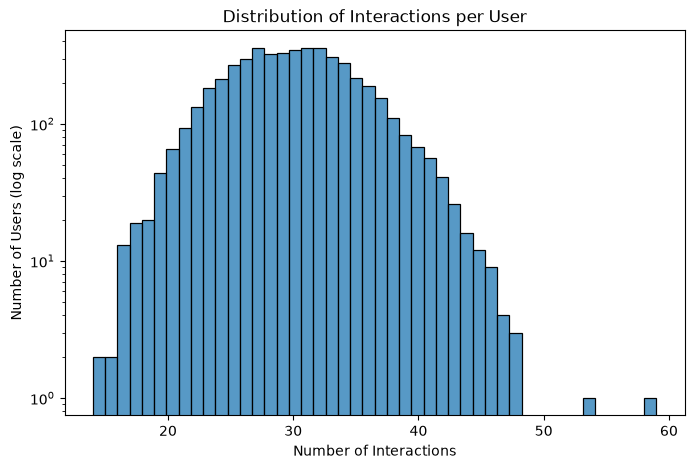

In [7]:
# Plot the distribution of interaction counts across users
plt.figure(figsize=(8, 5))

sns.histplot(
    interactions_per_user,
    bins=interactions_per_user.max() - interactions_per_user.min() + 1
)

# Use a logarithmic y-axis to make low-frequency parts
# of the distribution easier to inspect
plt.yscale("log")

plt.title("Distribution of Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users (log scale)")

plt.show()

### Interpretation

The median user has 30 interactions, and most users have roughly 20–40
interactions. The distribution is relatively balanced, with only a few users
in the high-activity tail and no extremely inactive users, since the minimum
is 14 interactions. This means that user activity is not strongly dominated
by a small group of highly active users, and every user has enough interaction
history to support later train/test splitting.

### 1.3 Interactions per Item

This section examines how many interaction records each item has received.
The distribution helps determine whether a small number of popular items
dominate the dataset or whether interactions are distributed more evenly
across items.

In [8]:
# Count the number of interaction records for each item
interactions_per_item = df.groupby("Item_ID").size()

# Display summary statistics
interactions_per_item.describe()

count    2000.000000
mean       75.000000
std         8.613658
min        51.000000
25%        69.000000
50%        75.000000
75%        81.000000
max       105.000000
dtype: float64

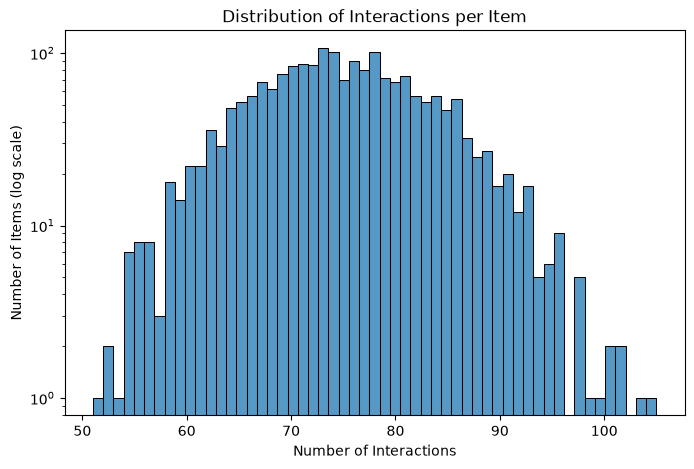

In [9]:
# Plot the distribution of interaction counts across items
plt.figure(figsize=(8, 5))

sns.histplot(
    interactions_per_item,
    bins=interactions_per_item.max() - interactions_per_item.min() + 1
)

# Use a logarithmic y-axis to inspect low-frequency parts of the distribution
plt.yscale("log")

plt.title("Distribution of Interactions per Item")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Items (log scale)")

plt.show()

### Interpretation

The median item has 75 interactions, and most items receive a relatively
similar number of interactions, with the middle 50% ranging from 69 to 81.
There is no strong long-tail pattern in item popularity, although a small
number of items appear at the low- and high-activity extremes. This relatively
balanced item activity suggests that popularity is less concentrated than in
many real-world recommendation datasets.

### 1.4 Rating Distribution

This section examines the distribution of the explicit rating signal. Understanding
the rating distribution helps determine whether user feedback is concentrated
around particular values or is relatively balanced across the rating scale.

In [10]:
# Display summary statistics for the rating values
df["Rating"].describe()

count    150000.000000
mean          2.994918
std           1.153429
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Rating, dtype: float64

Number of unique rating values: 41


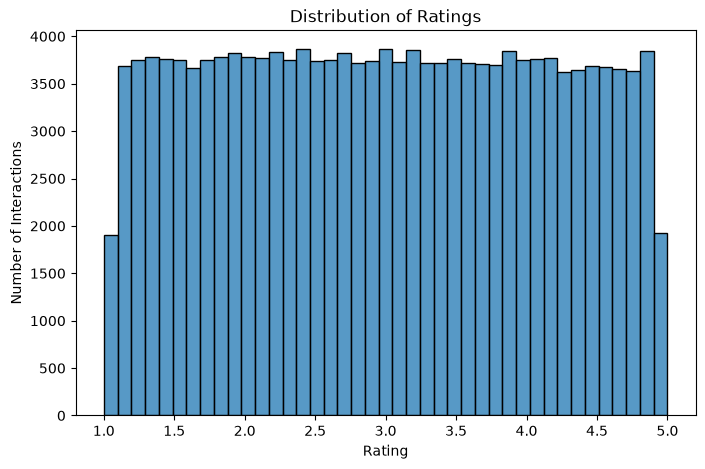

In [11]:
# Count the number of distinct rating values
num_unique_ratings = df["Rating"].nunique()

print("Number of unique rating values:", num_unique_ratings)

# Plot the distribution of ratings
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Rating"],
    bins=num_unique_ratings
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Interactions")

plt.show()

### Interpretation

The ratings are distributed relatively evenly across the 1.0–5.0 range, with
a mean of approximately 2.99 and a median of 3.0. There is no strong
concentration toward either high or low ratings, although the two endpoint
values, 1.0 and 5.0, occur less frequently than the intermediate values.
This balanced distribution means that the explicit feedback signal is not
strongly biased toward positive or negative ratings.

### 1.5 Activity Over Time

This section examines how interaction activity changes over time. The goal is
to identify possible gaps, spikes, trends, or abrupt changes in the dataset
that may affect the temporal train/test split.

In [12]:
# Count interaction records for each month
monthly_interactions = (
    df.set_index("Timestamp")
      .resample("ME")
      .size()
)

# Display monthly interaction counts
monthly_interactions

Timestamp
2022-12-31    1620
2023-01-31    6399
2023-02-28    5780
2023-03-31    6432
2023-04-30    6101
2023-05-31    6441
2023-06-30    6219
2023-07-31    6330
2023-08-31    6285
2023-09-30    6273
2023-10-31    6453
2023-11-30    6059
2023-12-31    6287
2024-01-31    6428
2024-02-29    5875
2024-03-31    6264
2024-04-30    6046
2024-05-31    6248
2024-06-30    6258
2024-07-31    6384
2024-08-31    6404
2024-09-30    6294
2024-10-31    6321
2024-11-30    6147
2024-12-31    4652
Freq: ME, dtype: int64

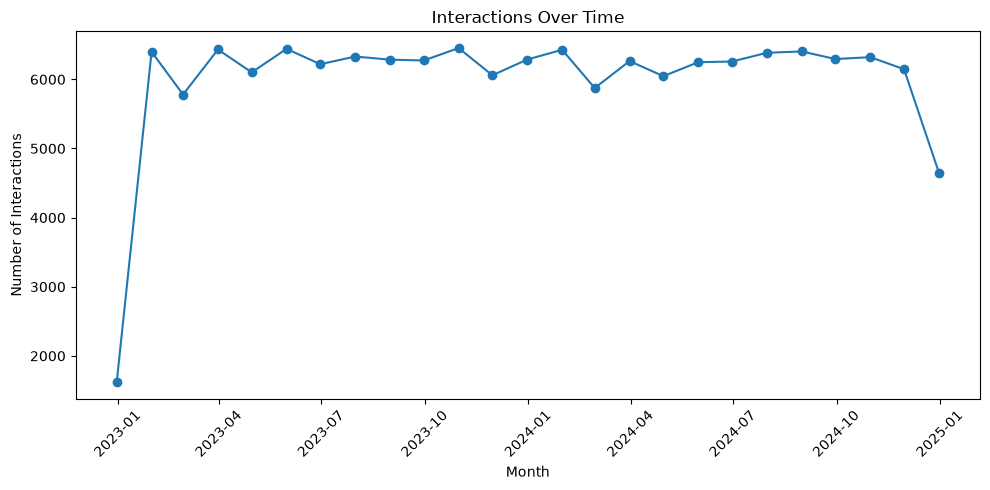

In [13]:
# Plot the number of interactions over time
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_interactions.index,
    monthly_interactions.values,
    marker="o"
)

plt.title("Interactions Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Interactions")

# Rotate date labels to improve readability
plt.xticks(rotation=45)

# Adjust spacing so labels fit inside the figure
plt.tight_layout()

plt.show()

### Interpretation

Interaction activity is relatively stable across the complete months in the
dataset, with no major gaps, spikes, or long-term increasing or decreasing
trend. The unusually low counts at the beginning and end are caused by partial
months, since the dataset starts on 2022-12-24 and ends on 2024-12-23. This
stable temporal activity makes a time-based evaluation split appropriate
without an obvious large-scale temporal disruption in the interaction volume.

### 1.6 Additional Data Quality Checks

Before modelling, we also check whether repeated user-item interactions exist
and whether the apparent categorical columns behave as stable user or item
attributes.

In [14]:
# Check whether contextual columns behave as stable user/item attributes
categories_per_item = df.groupby("Item_ID")["Category"].nunique()
prices_per_item = df.groupby("Item_ID")["Price"].nunique()
locations_per_user = df.groupby("User_ID")["Location"].nunique()
platforms_per_user = df.groupby("User_ID")["Platform"].nunique()

print("\nCategories per item:")
print(categories_per_item.describe())

print("\nPrices per item:")
print(prices_per_item.describe())

print("\nLocations per user:")
print(locations_per_user.describe())

print("\nPlatforms per user:")
print(platforms_per_user.describe())


Categories per item:
count    2000.000000
mean        8.999000
std         0.031615
min         8.000000
25%         9.000000
50%         9.000000
75%         9.000000
max         9.000000
Name: Category, dtype: float64

Prices per item:
count    2000.00000
mean       74.93600
std         8.60011
min        51.00000
25%        69.00000
50%        74.00000
75%        81.00000
max       105.00000
Name: Price, dtype: float64

Locations per user:
count    5000.00000
mean        5.96060
std         0.19661
min         4.00000
25%         6.00000
50%         6.00000
75%         6.00000
max         6.00000
Name: Location, dtype: float64

Platforms per user:
count    5000.000000
mean        3.997800
std         0.046857
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: Platform, dtype: float64


### Interpretation

Repeated user-item interactions identified earlier must also be considered when
designing the temporal evaluation split, because the same user-item pair can
appear in both training and test periods. This will also need to be considered when
constructing the interaction matrix, since each matrix cell represents a single user-item pair regardless of how many times that interaction occurs.

The consistency checks also show that the contextual columns do not behave as
fixed user or item attributes. Items appear with multiple `Category` and
`Price` values, while users appear with multiple `Location` and `Platform`
values. Therefore, these columns should primarily be treated as
interaction/context information rather than permanent user or item metadata.

## 2. Recommendation Model Type

The goal of this project is to produce a ranked top-N list of unseen items for
each user rather than predict exact rating values. Although the dataset contains
explicit ratings, top-N ranking is more appropriate because the final goal of
the recommendation system is to decide which unseen items should be recommended
to each user and in what order. Therefore, the system will rank candidate items
for each user and return the top 10 recommendations. We set N = 10 because it
provides a short and practical recommendation list while still allowing ranking
quality to be evaluated.

## 3. Temporal Train-Test Split

Because the dataset contains timestamps, we use a temporal split instead of a
random row-wise split. The model is trained only on earlier interactions and
evaluated on later interactions, which better reflects how a recommender would
operate in practice. Interactions before 2024-10-01 are used for training, while interactions on or after 2024-10-01 are reserved for testing. This keeps the evaluation chronologically realistic and prevents future information from leaking into the training process.

In [15]:
# Import reusable project functions and variables
from src.split import temporal_split

In [16]:
# Create the temporal train-test split using the reusable split function
train_df, test_df = temporal_split(df)

print("Training interactions:", len(train_df))
print("Test interactions:", len(test_df))

print("\nTraining date range:")
print(train_df["Timestamp"].min(), "to", train_df["Timestamp"].max())

print("\nTest date range:")
print(test_df["Timestamp"].min(), "to", test_df["Timestamp"].max())

Training interactions: 132880
Test interactions: 17120

Training date range:
2022-12-24 00:00:00 to 2024-09-30 00:00:00

Test date range:
2024-10-01 00:00:00 to 2024-12-23 00:00:00


### Cold-Start and User Activity Analysis

Before evaluating the recommender, we check whether the temporal split creates any cold-start users or items. A cold-start user or item appears in the test set but has never appeared in the training set. Such cases are important because a model trained only on historical interactions may not have enough information to generate meaningful recommendations for them.

We also check for users with only one interaction in the full dataset, since extremely low user activity can make both training and evaluation difficult.

In [17]:
# Get the users and items that appear in each split
train_users = set(train_df["User_ID"])
test_users = set(test_df["User_ID"])

train_items = set(train_df["Item_ID"])
test_items = set(test_df["Item_ID"])

# Users/items that appear in test but were never observed during training
cold_start_users = test_users - train_users
cold_start_items = test_items - train_items

print("Cold-start users:", len(cold_start_users))
print("Cold-start items:", len(cold_start_items))


# Count users that have only one interaction in the full dataset
user_interaction_counts = df.groupby("User_ID").size()
one_interaction_users = user_interaction_counts[user_interaction_counts == 1]

print("Users with only one interaction:", len(one_interaction_users))

Cold-start users: 0
Cold-start items: 0
Users with only one interaction: 0


### Interpretation

The temporal split produces no cold-start users or cold-start items, and no user has only one interaction in the full dataset. Therefore, all evaluation users and items were already observable during training, and no special cold-start handling is required for this split.

### Building the Evaluation Set

The test set may contain user-item pairs that were already observed during the training period. Since the goal is to recommend unseen items, these repeated pairs should not be treated as relevant targets during evaluation.

Therefore, we create a separate evaluation set by removing test interactions whose user-item pair already exists in the training data. This ensures that the recommender is evaluated only on future interactions with previously unseen items.

In [18]:
# Import reusable project functions and variables
from src.split import build_evaluation_set

In [19]:
# Build the evaluation set by removing user-item pairs already seen in training
evaluation_df = build_evaluation_set(train_df, test_df)

# Summarize how repeated user-item interactions affect the evaluation set
print("Original test interactions:", len(test_df))
print("Evaluation interactions:", len(evaluation_df))
print("Removed repeated interactions:", len(test_df) - len(evaluation_df))

Original test interactions: 17120
Evaluation interactions: 16875
Removed repeated interactions: 245


### Evaluation Split Decisions

The temporal split contains no cold-start users or items. However, 245 test interactions correspond to user-item pairs that were already observed during training. Since this project evaluates recommendations over unseen items, these repeated pairs are removed from the evaluation targets.

After filtering, the final evaluation set contains 16,875 interactions.

## 4. Baseline Models

Before implementing more advanced recommendation models, two simple baselines are created: Most Popular and Random. These baselines provide reference points for evaluating whether the later recommendation models actually learn useful user-item patterns.

Both baselines generate top-10 recommendations and exclude items that the user has already interacted with during the training period. Their performance will later be evaluated using the same ranking metrics as the more advanced models.

### 4.1 Most Popular Baseline

The Most Popular baseline ranks items according to their total number of interactions in the training set. For each user, items already observed during training are excluded before selecting the top 10 items. This provides a simple non-personalized benchmark that more advanced recommendation models should ideally outperform.

In [20]:
# Import reusable project functions and variables
from src.config import TOP_K
from src.baselines import recommend_most_popular

In [21]:
# Select one user from the evaluation set for a quick baseline check
sample_user = evaluation_df["User_ID"].iloc[0]

# Generate the top-10 most popular unseen items for this user
popular_recommendations = recommend_most_popular(
    train_df,
    sample_user,
    k=TOP_K
)

print("User:", sample_user)
print("Recommendations:", popular_recommendations)

User: User_3787
Recommendations: ['Item_276', 'Item_507', 'Item_1938', 'Item_1617', 'Item_595', 'Item_1329', 'Item_1905', 'Item_286', 'Item_234', 'Item_1061']


In [22]:
# Check that none of the recommended items were already seen in training
seen_items = set(
    train_df.loc[
        train_df["User_ID"] == sample_user,
        "Item_ID"
    ]
)

already_seen_popular = set(popular_recommendations) & seen_items

print("Recommended items already seen:", already_seen_popular)

Recommended items already seen: set()


### 4.2 Random Baseline

The Random baseline selects 10 unseen items randomly from the training catalog for each user. It does not use item popularity or user preferences, so it serves as a lower-bound reference for evaluating whether the recommendation models learn meaningful patterns.

In [23]:
# Import reusable project functions and variables
from src.baselines import recommend_random

In [24]:
# Generate 10 random unseen recommendations for the same sample user
random_recommendations = recommend_random(
    train_df,
    sample_user,
    k=TOP_K
)

print("User:", sample_user)
print("Random recommendations:", random_recommendations)

User: User_3787
Random recommendations: ['Item_903', 'Item_1219', 'Item_919', 'Item_1875', 'Item_13', 'Item_371', 'Item_662', 'Item_672', 'Item_611', 'Item_295']


In [25]:
# Check that random recommendations also exclude seen items
already_seen_random = set(random_recommendations) & seen_items

print("Random recommended items already seen:", already_seen_random)

Random recommended items already seen: set()


#### Verifying the Number of Evaluation Users

Recommendations are generated only for users who appear in the evaluation set. These users have at least one unseen interaction in the test period, which gives us ground-truth items that can later be compared with the generated recommendations.

The unique user IDs are therefore extracted from `evaluation_df` before generating recommendations for all evaluation users.

In [26]:
# Get the unique users that appear in the evaluation set
evaluation_users = evaluation_df["User_ID"].unique()

print("Number of evaluation users:", len(evaluation_users))

Number of evaluation users: 4815


#### Generating Popular Recommendations for All Evaluation Users

After verifying the Most Popular baseline on a single sample user, the recommender is applied to all 4,815 evaluation users. For each user, the model generates 10 popular items that were not seen during the training period.

The resulting recommendations will later be compared with the users' actual interactions in the evaluation set.

In [27]:
# Import reusable project functions and variables
from src.baselines import generate_baseline_recommendations_for_users

In [28]:
# Generate Most Popular recommendations for all evaluation users
popular_recommendations_all = generate_baseline_recommendations_for_users(
    train_df,
    evaluation_users,
    recommend_most_popular
)

# Check how many users received recommendations
print("Users with Most Popular recommendations:", len(popular_recommendations_all))

Users with Most Popular recommendations: 4815


#### Generating Random Recommendations for All Evaluation Users

After validating the Random baseline on a sample user, the same procedure is applied to all evaluation users. Each user receives 10 randomly selected unseen items, providing a simple lower-bound benchmark for later metric comparisons.

The resulting recommendations will again be compared with the users' actual interactions in the evaluation set.

In [29]:
# Generate Random recommendations for all evaluation users
random_recommendations_all = generate_baseline_recommendations_for_users(
    train_df,
    evaluation_users,
    recommend_random
)

# Check how many users received recommendations
print("Users with Random recommendations:", len(random_recommendations_all))

Users with Random recommendations: 4815


## 5. Model A: Item-Item kNN Collaborative Filtering

The first recommendation model uses item-item collaborative filtering. Items are represented by their user interaction patterns, and cosine distance is used to identify items with similar audiences.

For each user, candidate items are scored according to their similarity to items previously seen by that user. The highest-scoring unseen items are returned as the personalized top-N recommendation list.

### 5.1 Building the User-Item Interaction Matrix

The item-item kNN model first represents the training data as a sparse user-item matrix. Each row corresponds to a user and each column corresponds to an item. Since the goal is top-N recommendation of unseen items, interactions are represented as binary values: a value of 1 indicates that the user interacted with the item during the training period.

Repeated interactions between the same user and item are treated as a single interaction. A sparse matrix representation is used because most possible user-item pairs have no observed interaction.

In [30]:
# Import reusable project functions and variables
from src.models.item_knn import build_user_item_matrix

In [31]:
# Build the sparse user-item interaction matrix
user_item_matrix, user_to_index, index_to_item = (
    build_user_item_matrix(train_df)
)

# Inspect the dimensions of the user-item matrix
print("Matrix shape:", user_item_matrix.shape)

Matrix shape: (5000, 2000)


#### Matrix Validation

Before using the matrix for kNN, we verify that the number of stored non-zero entries matches the number of unique user-item pairs in the training data. This confirms that repeated interactions were correctly collapsed into a single binary interaction.

In [32]:
# Count the number of unique user-item pairs in the training data
unique_train_pairs = (
    train_df[["User_ID", "Item_ID"]]
    .drop_duplicates()
    .shape[0]
)

# Verify that each unique user-item pair corresponds to one non-zero matrix entry
print("Unique train user-item pairs:", unique_train_pairs)
print("Matrix non-zero entries:", user_item_matrix.nnz)

Unique train user-item pairs: 132026
Matrix non-zero entries: 132026


### 5.2 Fitting the Item-Item kNN Model

The item-item kNN model is fitted on the transposed item-user matrix using cosine distance. Each item is represented by its interaction pattern across users, allowing the model to identify items that were interacted with by similar groups of users.

The model uses brute-force nearest-neighbor search, which directly compares item vectors using cosine distance. At this stage, the model only learns how to identify neighboring items; user-specific recommendations will be generated later.

In [33]:
# Import reusable project functions and variables
from src.models.item_knn import fit_item_knn

In [34]:
# Fit the item-item kNN model on the item-user interaction matrix
knn_model, item_user_matrix = fit_item_knn(user_item_matrix)

print("Item-item kNN model fitted successfully.")

Item-item kNN model fitted successfully.


#### Inspecting Nearest Neighbors

Before generating user-specific recommendations, we inspect the nearest neighbors of a single item. This provides a simple sanity check that the fitted kNN model can identify items with similar user-interaction patterns.

Since scikit-learn returns cosine distances, smaller values indicate more similar items. Cosine similarity can be obtained as `1 - cosine distance`.

In [35]:
# Select the first item as a simple example
sample_item_index = 0
sample_item_id = index_to_item[sample_item_index]

# Find the item itself and its five nearest neighbors
distances, indices = knn_model.kneighbors(
    item_user_matrix[sample_item_index],
    n_neighbors=6
)

print("Sample item:", sample_item_id)
print("Neighbor indices:", indices[0])
print("Cosine distances:", distances[0])

Sample item: Item_52
Neighbor indices: [   0 1064 1630  947 1238  599]
Cosine distances: [0.         0.9205949  0.92247829 0.92247829 0.92790627 0.93428479]


#### Converting Neighbor Indices to Item IDs

The kNN model returns the row indices of neighboring items in the item-user matrix. To make the results interpretable, these indices are converted back to the original `Item_ID` values using the `index_to_item` mapping.

The first result is skipped because it corresponds to the queried item itself.

In [36]:
# Display the five nearest items with their cosine similarities
for neighbor_index, distance in zip(indices[0][1:], distances[0][1:]):
    neighbor_item_id = index_to_item[neighbor_index]
    similarity = 1 - distance

    print(
        neighbor_item_id,
        "Similarity:",
        round(similarity, 4)
    )

Item_173 Similarity: 0.0794
Item_182 Similarity: 0.0775
Item_541 Similarity: 0.0775
Item_1436 Similarity: 0.0721
Item_552 Similarity: 0.0657


### 5.3 Generating User-Specific Candidate Scores

To generate recommendations for a user, the model first identifies the items that the user interacted with during training. For each of these seen items, the kNN model retrieves similar items.

A candidate item's score is computed by summing its cosine similarities across the user's seen items. Therefore, an item can receive a higher score if it is similar to multiple items in the user's interaction history. Items already seen by the user are excluded from the final recommendation list.

In [37]:
# Select one user for testing
sample_user_id = evaluation_users[0]

# Convert the original user ID to its matrix row index
sample_user_index = user_to_index[sample_user_id]

# Retrieve the column indices of items already seen by the user
seen_item_indices = user_item_matrix[sample_user_index].indices

print("Sample user:", sample_user_id)
print("Number of seen items:", len(seen_item_indices))

Sample user: User_3787
Number of seen items: 24


In [38]:
# Find nearest neighbors for all items previously seen by the sample user
distances, neighbor_indices = knn_model.kneighbors(
    item_user_matrix[seen_item_indices],
    n_neighbors=6
)

print("Neighbor index matrix shape:", neighbor_indices.shape)
print("Distance matrix shape:", distances.shape)

Neighbor index matrix shape: (24, 6)
Distance matrix shape: (24, 6)


### 5.4 Implementing the Item-Item kNN Recommender

The recommendation function combines the previous steps into a reusable pipeline for generating personalized top-N recommendations. Given a user, it first identifies the items that the user interacted with during training.

For each seen item, the model retrieves its nearest neighbors using cosine distance. The similarity scores of candidate items are accumulated across the user's interaction history, allowing items that are similar to multiple seen items to receive higher scores. Previously seen items are excluded, and the highest-scoring unseen items are returned as the final recommendations.

The number of neighbors considered for each seen item is controlled by `KNN_NEIGHBORS`, while the number of final recommendations is controlled by `TOP_K`.

In [39]:
# Import reusable project functions and variables
from src.models.item_knn import recommend_item_knn

In [40]:
# Generate item-item kNN recommendations for the sample user
knn_recommendations = recommend_item_knn(
    sample_user_id,
    user_item_matrix,
    user_to_index,
    index_to_item,
    knn_model,
    item_user_matrix
)

print("Sample user:", sample_user_id)
print("Recommendations:", knn_recommendations)

Sample user: User_3787
Recommendations: ['Item_1836', 'Item_64', 'Item_1517', 'Item_1467', 'Item_37', 'Item_106', 'Item_30', 'Item_443', 'Item_384', 'Item_1015']


#### Verifying Seen-Item Exclusion

A recommendation system should not recommend items that the user has already interacted with during training. To verify this behavior, the generated kNN recommendations are compared with the sample user's training history. The intersection between these two sets should be empty.

In [41]:
# Get the original item IDs previously seen by the sample user
seen_item_ids = {
    index_to_item[item_index]
    for item_index in seen_item_indices
}

# Check whether any recommended item was already seen
seen_recommendations = set(knn_recommendations) & seen_item_ids

print("Seen recommendations:", seen_recommendations)

Seen recommendations: set()


#### Item-Item kNN Result

The item-item kNN model successfully generated 10 personalized recommendations for the sample user. The seen-item exclusion check returned an empty set, confirming that none of the recommended items had appeared in the user's training history.

This model represents the collaborative-filtering component of the recommendation pipeline. Item similarity is based only on user interaction patterns, without using item metadata such as category, price, or platform.

### 5.5 Generating kNN Recommendations for All Evaluation Users

After validating the item-item kNN model on a single user, the same recommendation procedure is applied to all users in the evaluation set.

For each user, the model generates the top-K unseen items using the fitted item-item similarity model. The resulting recommendation lists are stored for later dataset-level evaluation.

In [42]:
# Import reusable project functions and variables
from src.models.item_knn import generate_item_knn_recommendations_for_users

In [43]:
knn_recommendations_all = generate_item_knn_recommendations_for_users(
    evaluation_users,
    user_item_matrix,
    user_to_index,
    index_to_item,
    knn_model,
    item_user_matrix,
    k=TOP_K
)

print("Users with kNN recommendations:", len(knn_recommendations_all))

Users with kNN recommendations: 4815


## 6. Model B: Feature-Based Recommendation with LightGBM

The second recommendation model uses engineered features describing the user, item, and user-item interaction context. Unlike the collaborative-filtering kNN model, this approach learns a supervised prediction function from feature values.

The training data will contain positive user-item interactions together with sampled negative user-item pairs that were not observed during training. Care must be taken to avoid using future information when constructing features.

### 6.1 Constructing Training Examples

The LightGBM model is trained as a binary classifier over user-item pairs. Observed user-item interactions from the training period are treated as positive examples with a label of 1.

Because the dataset only records observed interactions, negative examples are not explicitly available. Therefore, unseen user-item pairs will be sampled from the training catalog and assigned a label of 0. This negative sampling step allows the model to learn to distinguish likely interactions from non-interactions.

In [44]:
# Create positive training examples from observed user-item pairs
positive_examples = (
    train_df[["User_ID", "Item_ID"]]
    .drop_duplicates()
    .copy()
)

# Observed interactions are positive examples
positive_examples["label"] = 1

print(positive_examples.head())
print("Number of positive examples:", len(positive_examples))

     User_ID    Item_ID  label
0   User_913    Item_52      1
1  User_3457    Item_66      1
2  User_1629  Item_1467      1
3  User_3463   Item_697      1
4  User_2941  Item_1736      1
Number of positive examples: 132026


#### Defining Positive Interactions

Because the prediction task is top-N recommendation rather than rating
prediction, every observed user-item interaction is treated as a positive
example regardless of its rating value. Ratings are instead used as historical
features. Therefore, the model learns interaction likelihood rather than
whether a user will give an item a high rating.

#### Negative Sampling

The dataset contains observed interactions but does not explicitly identify items that users disliked or would not interact with. To train a binary classifier, negative examples are therefore sampled from user-item pairs that were not observed during the training period.

For each positive interaction, an unseen item will be sampled for the same user and assigned a label of 0. This creates a balanced training dataset with both positive and negative examples.

In [45]:
# Import reusable project functions and variables
from src.models.lightgbm_model import sample_negative_examples

In [46]:
# Generate negative training examples
negative_examples = sample_negative_examples(train_df)

print(negative_examples.head())
print("Number of negative examples:", len(negative_examples))

  User_ID    Item_ID  label
0  User_1   Item_998      0
1  User_1  Item_1524      0
2  User_1   Item_391      0
3  User_1  Item_1864      0
4  User_1  Item_1729      0
Number of negative examples: 132026


#### Validating Negative Samples

Before using the sampled negatives for model training, several checks are performed to verify that the sampling process is correct. The number of negative examples should match the number of positive examples, negative pairs should not overlap with observed positive pairs, and duplicate negative user-item pairs should not exist.

In [47]:
# Convert positive and negative user-item pairs to sets
positive_pairs_set = set(
    zip(positive_examples["User_ID"], positive_examples["Item_ID"])
)

negative_pairs_set = set(
    zip(negative_examples["User_ID"], negative_examples["Item_ID"])
)

# Check for overlap between positive and negative pairs
overlap = positive_pairs_set & negative_pairs_set

# Check for duplicate negative pairs
duplicate_negatives = negative_examples.duplicated(
    subset=["User_ID", "Item_ID"]
).sum()

print("Number of positive examples:", len(positive_examples))
print("Number of negative examples:", len(negative_examples))
print("Positive-negative overlap:", len(overlap))
print("Duplicate negative pairs:", duplicate_negatives)

Number of positive examples: 132026
Number of negative examples: 132026
Positive-negative overlap: 0
Duplicate negative pairs: 0


### 6.2 Building the LightGBM Training Dataset

The validated positive and negative examples are combined into a single training dataset. Each row represents a user-item pair, while the `label` column indicates whether the pair corresponds to an observed interaction (`1`) or a sampled unseen interaction (`0`).

The combined dataset will next be enriched with user and item features before being used to train the LightGBM model.

In [48]:
# Combine positive and negative examples into one dataset
training_examples = pd.concat(
    [positive_examples, negative_examples],
    ignore_index=True
)

print(training_examples.head())
print("Training examples:", len(training_examples))
print(training_examples["label"].value_counts())

     User_ID    Item_ID  label
0   User_913    Item_52      1
1  User_3457    Item_66      1
2  User_1629  Item_1467      1
3  User_3463   Item_697      1
4  User_2941  Item_1736      1
Training examples: 264052
label
1    132026
0    132026
Name: count, dtype: int64


### 6.3 User and Item Activity Features

The first engineered features describe general user activity and item popularity. All feature statistics are computed only from the training period to avoid future-data leakage.

- `user_interaction_count`: number of training interactions made by the user.
- `item_interaction_count`: number of training interactions received by the item.

These features provide information about how active a user is and how frequently an item appears in the historical interaction data.

In [49]:
# Count the number of training interactions for each user
user_interaction_counts = (
    train_df.groupby("User_ID")
    .size()
)

print(user_interaction_counts.head())

User_ID
User_1       25
User_10      33
User_100     25
User_1000    32
User_1001    27
dtype: int64


In [50]:
# Count the number of training interactions for each item
item_interaction_counts = (
    train_df.groupby("Item_ID")
    .size()
)

print(item_interaction_counts.head())

Item_ID
Item_1       77
Item_10      58
Item_100     50
Item_1000    73
Item_1001    73
dtype: int64


In [51]:
# Add user activity and item popularity features
training_examples["user_interaction_count"] = (
    training_examples["User_ID"]
    .map(user_interaction_counts)
)

training_examples["item_interaction_count"] = (
    training_examples["Item_ID"]
    .map(item_interaction_counts)
)

print(training_examples.head())

     User_ID    Item_ID  label  user_interaction_count  item_interaction_count
0   User_913    Item_52      1                      23                      65
1  User_3457    Item_66      1                      31                      60
2  User_1629  Item_1467      1                      17                      48
3  User_3463   Item_697      1                      27                      83
4  User_2941  Item_1736      1                      21                      84


#### User Tenure

User tenure represents how long a user has been present in the system. It is
defined as the number of days between the user's first observed interaction
and the end of the training period. Both dates are derived only from the
training data, preventing future-data leakage.

In [52]:
# Use the latest training timestamp as the end of the observed training period
training_reference_date = train_df["Timestamp"].max()

# Find each user's first observed interaction
user_first_interactions = (
    train_df.groupby("User_ID")["Timestamp"]
    .min()
)

# Calculate how many days each user has been present in the system
user_tenure_days = (
    training_reference_date - user_first_interactions
).dt.days

# Add user tenure to the training examples
training_examples["user_tenure_days"] = (
    training_examples["User_ID"]
    .map(user_tenure_days)
)

In [53]:
print(training_examples[
    ["User_ID", "user_tenure_days"]
].head())

     User_ID  user_tenure_days
0   User_913               635
1  User_3457               639
2  User_1629               617
3  User_3463               625
4  User_2941               602


### 6.4 Historical Rating Features

The dataset also contains explicit ratings, but the rating of a future unseen user-item interaction would not be available when generating recommendations. Therefore, the raw rating of a candidate pair is not used as a feature.

Instead, historical rating statistics are computed from the training period:

- `user_mean_rating`: average rating given by the user during training.
- `item_mean_rating`: average rating received by the item during training.
- `rating_difference`: absolute difference between the user's historical mean rating and the item's historical mean rating.

The difference feature provides a simple user-item compatibility signal while using only historical information.

In [54]:
# Calculate the average rating given by each user
user_mean_ratings = (
    train_df.groupby("User_ID")["Rating"]
    .mean()
)

# Calculate the average rating received by each item
item_mean_ratings = (
    train_df.groupby("Item_ID")["Rating"]
    .mean()
)

print(user_mean_ratings.head())
print(item_mean_ratings.head())

User_ID
User_1       3.072000
User_10      3.051515
User_100     3.296000
User_1000    3.034375
User_1001    3.185185
Name: Rating, dtype: float64
Item_ID
Item_1       2.993506
Item_10      2.994828
Item_100     3.172000
Item_1000    2.856164
Item_1001    3.036986
Name: Rating, dtype: float64


In [55]:
# Add historical rating features
training_examples["user_mean_rating"] = (
    training_examples["User_ID"]
    .map(user_mean_ratings)
)

training_examples["item_mean_rating"] = (
    training_examples["Item_ID"]
    .map(item_mean_ratings)
)

print(training_examples.head())

     User_ID    Item_ID  label  user_interaction_count  \
0   User_913    Item_52      1                      23   
1  User_3457    Item_66      1                      31   
2  User_1629  Item_1467      1                      17   
3  User_3463   Item_697      1                      27   
4  User_2941  Item_1736      1                      21   

   item_interaction_count  user_tenure_days  user_mean_rating  \
0                      65               635          3.139130   
1                      60               639          2.970968   
2                      48               617          2.611765   
3                      83               625          3.140741   
4                      84               602          2.938095   

   item_mean_rating  
0          3.203077  
1          3.148333  
2          2.881250  
3          3.004819  
4          3.035714  


In [56]:
# Add a simple user-item rating compatibility feature
training_examples["rating_difference"] = abs(
    training_examples["user_mean_rating"]
    - training_examples["item_mean_rating"]
)

print(training_examples.head())

     User_ID    Item_ID  label  user_interaction_count  \
0   User_913    Item_52      1                      23   
1  User_3457    Item_66      1                      31   
2  User_1629  Item_1467      1                      17   
3  User_3463   Item_697      1                      27   
4  User_2941  Item_1736      1                      21   

   item_interaction_count  user_tenure_days  user_mean_rating  \
0                      65               635          3.139130   
1                      60               639          2.970968   
2                      48               617          2.611765   
3                      83               625          3.140741   
4                      84               602          2.938095   

   item_mean_rating  rating_difference  
0          3.203077           0.063946  
1          3.148333           0.177366  
2          2.881250           0.269485  
3          3.004819           0.135921  
4          3.035714           0.097619  


### 6.5 Historical Price Features

The exploratory analysis showed that `Price` is not a fixed attribute of an item, since the same item can appear with different prices across interactions. Therefore, a single raw price value is not treated as permanent item metadata.

Instead, historical price statistics are computed from the training period:

- `user_mean_price`: average price of items the user interacted with during training.
- `item_mean_price`: average historical price associated with the item.
- `price_difference`: absolute difference between the user's historical mean price and the item's historical mean price.

This provides a simple price compatibility signal without assuming that each item has one fixed price.

In [57]:
# Calculate the average price of items interacted with by each user
user_mean_prices = (
    train_df.groupby("User_ID")["Price"]
    .mean()
)

# Calculate the average historical price of each item
item_mean_prices = (
    train_df.groupby("Item_ID")["Price"]
    .mean()
)

print(user_mean_prices.head())
print(item_mean_prices.head())

User_ID
User_1       267.354000
User_10      252.725152
User_100     250.392800
User_1000    238.539375
User_1001    266.473704
Name: Price, dtype: float64
Item_ID
Item_1       241.931948
Item_10      270.922759
Item_100     220.619400
Item_1000    257.101918
Item_1001    233.244795
Name: Price, dtype: float64


In [58]:
# Add historical price features
training_examples["user_mean_price"] = (
    training_examples["User_ID"]
    .map(user_mean_prices)
)

training_examples["item_mean_price"] = (
    training_examples["Item_ID"]
    .map(item_mean_prices)
)

# Add a user-item price compatibility feature
training_examples["price_difference"] = abs(
    training_examples["user_mean_price"]
    - training_examples["item_mean_price"]
)

print(training_examples.head())

     User_ID    Item_ID  label  user_interaction_count  \
0   User_913    Item_52      1                      23   
1  User_3457    Item_66      1                      31   
2  User_1629  Item_1467      1                      17   
3  User_3463   Item_697      1                      27   
4  User_2941  Item_1736      1                      21   

   item_interaction_count  user_tenure_days  user_mean_rating  \
0                      65               635          3.139130   
1                      60               639          2.970968   
2                      48               617          2.611765   
3                      83               625          3.140741   
4                      84               602          2.938095   

   item_mean_rating  rating_difference  user_mean_price  item_mean_price  \
0          3.203077           0.063946       250.173913       222.778154   
1          3.148333           0.177366       239.260323       257.427167   
2          2.881250           0.

### 6.6 Final Feature Set

After constructing the activity, rating, and price features, the final LightGBM feature set contains nine numerical features. All historical statistics are computed exclusively from the training period to avoid future-data leakage.

The final feature set combines general user and item behavior with simple user-item compatibility signals derived from ratings and prices.

In [59]:
# Define the final feature set used by the LightGBM model
feature_columns = [
    "user_interaction_count",
    "user_tenure_days",
    "item_interaction_count",
    "user_mean_rating",
    "item_mean_rating",
    "rating_difference",
    "user_mean_price",
    "item_mean_price",
    "price_difference"
]

# Check that all engineered features are available for every training example
print(training_examples[feature_columns].isna().sum())

user_interaction_count    0
user_tenure_days          0
item_interaction_count    0
user_mean_rating          0
item_mean_rating          0
rating_difference         0
user_mean_price           0
item_mean_price           0
price_difference          0
dtype: int64


#### Missing Value Check

Before training the model, the engineered features are checked for missing
values. This ensures that every training example has a complete set of input
features.

### 6.7 Training the LightGBM Model

The engineered features and binary labels are now used to train a LightGBM classifier. The classifier learns patterns that distinguish observed user-item interactions from sampled unseen pairs.

After training, the model can assign an interaction probability to candidate user-item pairs. These probabilities will later be used as recommendation scores to rank unseen items for each user.

#### Why LGBMClassifier Instead of LGBMRanker?

`LGBMClassifier` treats each user-item pair as a binary example and learns the
probability of an interaction. This matches the negative-sampling approach used
in this project, where observed user-item pairs are labeled as positive and
sampled unseen pairs are labeled as negative.

`LGBMRanker`, in contrast, is designed to learn relative ordering within groups
of examples. In a recommendation setting, each user can form a separate group,
and the `group` parameter specifies how many training examples belong to each
user. The ranker then learns to order items within these user groups rather than
independently predicting a binary probability for every pair.

This project uses `LGBMClassifier` because the assignment defines the
feature-based model as a binary interaction-probability problem,
`P(interaction | user, item)`. The predicted positive-class probabilities are
therefore used directly as ranking scores.

In [60]:
# Import reusable project functions and variables
from src.models.lightgbm_model import fit_lightgbm_model

In [61]:
# Train the LightGBM classifier
lightgbm_model = fit_lightgbm_model(
    training_examples,
    feature_columns
)

[LightGBM] [Info] Number of positive: 132026, number of negative: 132026
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000710 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 264052, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


### 6.8 Feature Importance

Feature importance values provide a simple view of which engineered features contributed most to the LightGBM model's decisions. These values do not prove causality, but they help interpret which features the model relied on more heavily during training.

In [62]:
# Create a table containing feature names and their importance values
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": lightgbm_model.feature_importances_
})

# Sort features from most to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                  feature  importance
5       rating_difference         456
8        price_difference         452
2  item_interaction_count         351
6         user_mean_price         348
3        user_mean_rating         337
1        user_tenure_days         318
7         item_mean_price         305
4        item_mean_rating         251
0  user_interaction_count         182


#### Feature Importance Interpretation

The split-based feature importance values show that `price_difference` and `rating_difference` were used most frequently when constructing the LightGBM decision trees. This suggests that the model frequently relied on the user-item compatibility features when separating positive and negative training examples.

However, these values represent how often features were used for splits and should not be interpreted as causal effects or as proof that a feature is inherently more important for recommendation quality. Final model quality will instead be determined using the ranking metrics on the temporal evaluation set.

### 6.9 Generating Recommendations with LightGBM

To generate recommendations, the trained LightGBM model must score candidate items for a user. Candidate items are restricted to items observed in the training catalogue that the user has not previously interacted with.

The same feature definitions used during training must also be used when scoring these candidate user-item pairs. The model's raw predicted interaction probabilities are then used as recommendation scores, and the highest-scoring items form the top-N list.

In [63]:
# Import reusable project functions and variables
from src.models.lightgbm_model import add_lightgbm_features

In [64]:
# Recreate the features using the reusable feature function
recreated_examples = add_lightgbm_features(
    training_examples[["User_ID", "Item_ID", "label"]],
    train_df
)

# Check whether the recreated features match the original features
feature_match = (
    recreated_examples[feature_columns]
    == training_examples[feature_columns]
).all()

print(feature_match)

user_interaction_count    True
user_tenure_days          True
item_interaction_count    True
user_mean_rating          True
item_mean_rating          True
rating_difference         True
user_mean_price           True
item_mean_price           True
price_difference          True
dtype: bool


In [65]:
# Import reusable project functions and variables
from src.models.lightgbm_model import recommend_lightgbm

In [66]:
# Generate LightGBM recommendations for the sample user
lightgbm_recommendations = recommend_lightgbm(
    sample_user,
    train_df,
    lightgbm_model,
    feature_columns,
    k=10
)

print(
    lightgbm_recommendations[
        ["User_ID", "Item_ID", "score", "rank"]
    ]
)

        User_ID    Item_ID     score  rank
492   User_3787   Item_507  0.597050     1
11    User_3787   Item_286  0.581308     2
1599  User_3787  Item_1905  0.580261     3
714   User_3787  Item_1617  0.578832     4
1349  User_3787   Item_746  0.578378     5
66    User_3787  Item_1938  0.578340     6
1805  User_3787   Item_459  0.577884     7
907   User_3787  Item_1251  0.577671     8
589   User_3787   Item_832  0.576107     9
1010  User_3787  Item_1581  0.575431    10


In [67]:
# Collect items previously seen by the sample user
sample_seen_items = set(
    train_df.loc[
        train_df["User_ID"] == sample_user,
        "Item_ID"
    ]
)

# Check whether any recommended item was already seen
recommended_items = set(
    lightgbm_recommendations["Item_ID"]
)

print(
    "Seen items in recommendations:",
    sample_seen_items & recommended_items
)

Seen items in recommendations: set()


#### LightGBM Recommendation Check

The LightGBM model successfully generated 10 ranked candidate items for the sample user, with higher predicted interaction probabilities appearing first. The recommendations use the model's raw predicted probabilities as scores rather than rescaled per-user values.

The seen-item exclusion check returned an empty set, confirming that none of the recommended items had appeared in the user's training history.

### 6.10 Negative Sampling Ratio Experiments

The LightGBM model is initially trained with a 1:1 positive-to-negative sampling ratio. However, recommendation datasets usually contain far more unseen user-item pairs than observed interactions.

To examine how the amount of negative sampling affects recommendation performance, additional models will be trained using different negative sampling ratios. The models will later be compared using ranking metrics on the same temporal evaluation set.

In [68]:
# Import reusable project functions and variables
from src.config import NEGATIVE_SAMPLING_RATIOS

In [69]:
# Negative sampling ratios to compare
negative_ratios = NEGATIVE_SAMPLING_RATIOS

# Store the generated negative examples for each ratio
negative_examples_by_ratio = {}

# Generate negative samples for each sampling ratio
for ratio in negative_ratios:
    negatives = sample_negative_examples(
        train_df,
        negative_ratio=ratio
    )

    negative_examples_by_ratio[ratio] = negatives

    print(
        f"Ratio 1:{ratio} -> "
        f"{len(negatives)} negative examples"
    )

Ratio 1:1 -> 132026 negative examples
Ratio 1:3 -> 396078 negative examples
Ratio 1:5 -> 660130 negative examples
Ratio 1:10 -> 1320260 negative examples


In [70]:
# Store the full training dataset for each negative sampling ratio
training_examples_by_ratio = {}

for ratio in negative_ratios:
    # Combine positive examples with the negatives for this ratio
    ratio_training_examples = pd.concat(
        [
            positive_examples,
            negative_examples_by_ratio[ratio]
        ],
        ignore_index=True
    )

    # Add the same engineered features used by LightGBM
    ratio_training_examples = add_lightgbm_features(
        ratio_training_examples,
        train_df
    )

    # Store the completed training dataset
    training_examples_by_ratio[ratio] = ratio_training_examples

    print(
        f"Ratio 1:{ratio} -> "
        f"{len(ratio_training_examples)} total training examples"
    )

Ratio 1:1 -> 264052 total training examples
Ratio 1:3 -> 528104 total training examples
Ratio 1:5 -> 792156 total training examples
Ratio 1:10 -> 1452286 total training examples


In [71]:
# Store one trained LightGBM model for each negative sampling ratio
lightgbm_models_by_ratio = {}

for ratio in negative_ratios:
    # Train a model using the dataset for this ratio
    model = fit_lightgbm_model(
        training_examples_by_ratio[ratio],
        feature_columns
    )

    # Store the trained model for later evaluation
    lightgbm_models_by_ratio[ratio] = model

    print(f"Finished training model for ratio 1:{ratio}")

[LightGBM] [Info] Number of positive: 132026, number of negative: 132026
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 264052, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Finished training model for ratio 1:1
[LightGBM] [Info] Number of positive: 132026, number of negative: 396078
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 528104, number of used features: 9
[LightGBM] [Info] [binary:Boost

#### Negative Sampling Experiment Summary

Four LightGBM models were trained using negative sampling ratios of 1:1, 1:3, 1:5 and 1:10. Increasing the negative sampling ratio increased the size of the training dataset and reduced the proportion of positive examples, while the positive interactions remained unchanged across all experiments.

At this stage, no conclusion can be made about which sampling ratio performs best. The models must be compared on the same temporal evaluation set using top-K ranking metrics.

### 6.11 Generating LightGBM Recommendations for Each Negative Sampling Ratio

After training separate LightGBM models with negative sampling ratios of 1:1, 1:3, 1:5, and 1:10, each model is applied to the same set of evaluation users.

For every user, unseen candidate items are scored using the corresponding trained LightGBM model and the top-K items are retained. The resulting recommendation lists are stored separately for each negative sampling ratio so that their ranking performance can later be compared fairly using the same evaluation metrics.

In [72]:
# Import reusable project functions and variables
from src.models.lightgbm_model import generate_lightgbm_recommendations_for_users

In [73]:
# Store recommendations generated by each LightGBM ratio model
lightgbm_recommendations_by_ratio = {}

for ratio, model in lightgbm_models_by_ratio.items():
    recommendations = generate_lightgbm_recommendations_for_users(
        evaluation_users,
        train_df,
        model,
        feature_columns,
        k=TOP_K
    )

    lightgbm_recommendations_by_ratio[ratio] = recommendations

    print(
        f"Ratio 1:{ratio} -> "
        f"{len(recommendations)} users"
    )

Ratio 1:1 -> 4815 users
Ratio 1:3 -> 4815 users
Ratio 1:5 -> 4815 users
Ratio 1:10 -> 4815 users


## 7. Evaluation with Ranking Metrics

Recommendation models should be evaluated based on the quality of their ranked recommendation lists rather than standard classification accuracy. The temporal evaluation set contains the future unseen interactions that will be treated as relevant items for each user.

The following top-K ranking metrics will be implemented manually: Precision@K, Recall@K, MAP@K, NDCG@K, and Hit Rate@K. These metrics will be used consistently to compare the baseline models, item-item kNN, and the LightGBM models.

### 7.1 Single-User Metric Validation

Before applying the ranking metrics to the complete recommendation models, a small manually verifiable example is used to validate each implementation for a single user.

In [74]:
# Simple Test Example for single-user tests
test_recommendations = ["A", "B", "C", "D", "E"]
test_relevant_items = {"B", "D", "X"}

#### 7.1.1 Precision@K

Precision@K measures the proportion of the top-K recommended items that are relevant to the user. An item is considered relevant if it appears among the user's future unseen interactions in the evaluation set.

In [75]:
# Import reusable project functions and variables
from src.metrics import precision_at_k

In [76]:
# Test Precision@K with a simple example
precision_at_k(
    test_recommendations,
    test_relevant_items,
    k=5
)

0.4

#### 7.1.2 Recall@K

Recall@K measures the proportion of a user's relevant items that are successfully retrieved within the top-K recommendations. While Precision@K focuses on how many recommendations are relevant, Recall@K focuses on how much of the user's future relevant set is recovered.

In [77]:
# Import reusable project functions and variables
from src.metrics import recall_at_k

In [78]:
# Test Recall@K with the simple example
recall_at_k(
    test_recommendations,
    test_relevant_items,
    k=5
)

0.6666666666666666

#### 7.1.3 Hit Rate@K

Hit Rate@K indicates whether at least one relevant item appears within the top-K recommendations. For a single user, the metric is 1 if at least one relevant item is retrieved and 0 otherwise.

In [79]:
# Import reusable project functions and variables
from src.metrics import hit_rate_at_k 

In [80]:
# Test Hit Rate@K with the simple example
hit_rate_at_k(
    test_recommendations,
    test_relevant_items,
    k=5
)

1.0

#### 7.1.4 Average Precision@K

Average Precision@K evaluates a single user's ranked recommendation list by considering both whether relevant items are retrieved and how highly they are ranked. Each time a relevant item is encountered in the top-K list, the precision at that rank contributes to the score.

In this implementation, the accumulated precision is normalized by `min(number of relevant items, K)`.

In [81]:
# Import reusable project functions and variables
from src.metrics import average_precision_at_k

In [82]:
# Test Average Precision@K with the simple example
average_precision_at_k(
    test_recommendations,
    test_relevant_items,
    k=5
)

0.3333333333333333

#### 7.1.5 NDCG@K

NDCG@K evaluates the quality of a ranked recommendation list by giving higher importance to relevant items that appear near the top. DCG@K discounts relevant items according to their rank, while IDCG@K represents the best possible ranking for the same set of relevant items.

NDCG@K is calculated as DCG@K divided by IDCG@K, producing a normalized score where 1 represents an ideal ranking.

In [83]:
# Import reusable project functions and variables
from src.metrics import ndcg_at_k

In [84]:
from src.metrics import ndcg_at_k

test_recommendations = ["A", "B", "C", "D", "E"]
test_relevant_items = {"B", "D", "X"}

ndcg_at_k(
    test_recommendations,
    test_relevant_items,
    k=5
)

0.49818925746641285

#### Verifying NDCG@K with Scikit-learn

To verify the manual NDCG@K implementation, the same example is evaluated using `sklearn.metrics.ndcg_score`. Since Scikit-learn expects relevance labels and prediction scores rather than item IDs, binary relevance values are used for `y_true`, while descending scores are assigned to `y_score` to preserve the recommendation order.

The relevant item `X` is also included as a candidate but placed outside the top-5 ranking. This allows Scikit-learn to use the same set of relevant items when calculating the ideal ranking.

In [85]:
from sklearn.metrics import ndcg_score

# Relevance for candidates [A, B, C, D, E, X]
y_true = [[0, 1, 0, 1, 0, 1]]

# Preserve A > B > C > D > E > X ranking
y_score = [[6, 5, 4, 3, 2, 1]]

ndcg_score(y_true, y_score, k=5)    

0.49818925746641274

### 7.2 Dataset-Level Model Evaluation

The validated ranking metrics are now applied across all evaluation users to measure the overall performance of each recommendation model. Per-user metric values are aggregated across users, with MAP@K calculated as the mean of Average Precision@K values.

In [86]:
# Build the ground-truth relevant item set for each evaluation user
relevant_items_by_user = (
    evaluation_df
    .groupby("User_ID")["Item_ID"]
    .apply(set)
    .to_dict()
)

# Inspect one example user
sample_evaluation_user = evaluation_users[0]

sample_evaluation_user, relevant_items_by_user[sample_evaluation_user]

('User_3787', {'Item_265', 'Item_687', 'Item_778'})

#### 7.2.1 Evaluating the Most Popular Baseline

As a first dataset-level evaluation, the Most Popular baseline is evaluated using the previously implemented ranking metrics. The model's top-K recommendations for each evaluation user are compared against that user's future unseen relevant items.

This first evaluation also serves as a check that the dataset-level metric aggregation works correctly before applying the same procedure to the remaining recommendation models.

In [87]:
# Import reusable project functions and variables
from src.metrics import evaluate_recommendations

In [88]:
popular_metrics = evaluate_recommendations(
    popular_recommendations_all,
    relevant_items_by_user,
    k=TOP_K
)

popular_metrics

{'precision_at_k': 0.0017445482866043614,
 'recall_at_k': 0.005025630882328702,
 'hit_rate_at_k': 0.017445482866043614,
 'map_at_k': 0.0015755158684372945,
 'ndcg_at_k': 0.003427239024756183}

The Most Popular baseline achieves very low ranking scores across all metrics. Only a small fraction of users receive at least one relevant recommendation in the top-10 list, and both MAP@K and NDCG@K are close to zero. This indicates that globally popular items alone are not sufficient to capture individual user preferences in this dataset.

#### 7.2.2 Evaluating the Random Baseline

The Random baseline is evaluated using the same dataset-level ranking metrics as the Most Popular baseline. Each evaluation user receives randomly selected unseen items, so this model provides a lower-bound reference for recommendation quality.

Its performance will be compared with the Most Popular baseline and the learned recommendation models.

In [89]:
random_metrics = evaluate_recommendations(
    random_recommendations_all,
    relevant_items_by_user,
    k=TOP_K
)

random_metrics

{'precision_at_k': 0.0018068535825545174,
 'recall_at_k': 0.004559412550066756,
 'hit_rate_at_k': 0.017860851505711317,
 'map_at_k': 0.0012255098704994864,
 'ndcg_at_k': 0.0030484033100998645}

The Random baseline performs similarly to the Most Popular baseline, with small differences across the ranking metrics. It achieves slightly higher Precision@K and Hit Rate@K, while the Most Popular baseline performs better in Recall@K, MAP@K, and NDCG@K.

Overall, both baselines remain weak in terms of ranking accuracy, suggesting that neither random selection nor global popularity alone captures enough information about individual user preferences.

#### 7.2.3 Evaluating the Item-Item kNN Model

The item-item kNN model is evaluated across all users in the evaluation set. For each user, candidate items are scored based on their cosine similarity to items that the user interacted with during the training period.

The model excludes previously seen items and returns the top-K unseen recommendations. These recommendation lists are then compared with each user's future unseen relevant items using the same ranking metrics as the baseline models.

In [90]:
knn_metrics = evaluate_recommendations(
    knn_recommendations_all,
    relevant_items_by_user,
    k=TOP_K
)

knn_metrics

{'precision_at_k': 0.00161993769470405,
 'recall_at_k': 0.004147917387792777,
 'hit_rate_at_k': 0.015991692627206646,
 'map_at_k': 0.001138000186806002,
 'ndcg_at_k': 0.002758755695007817}

The item-item kNN model performs worse than both baseline models across all ranking metrics. This suggests that, for this dataset and the current binary interaction representation, local item-item similarity does not capture enough useful structure to improve top-K recommendation quality.

Although the model uses collaborative-filtering information rather than global popularity alone, its lower MAP@K and NDCG@K indicate that relevant items are not being ranked effectively near the top of the recommendation lists.

#### 7.2.4 Evaluating LightGBM Across Negative Sampling Ratios

The LightGBM models trained with negative sampling ratios of 1:1, 1:3, 1:5, and 1:10 are evaluated on the same set of evaluation users.

For each ratio, the previously generated top-K recommendation lists are compared with the same future unseen relevant items. Using the same evaluation set and ranking metrics makes the comparison between negative sampling ratios fair.

In [91]:
# Store evaluation metrics for each LightGBM negative sampling ratio
lightgbm_metrics_by_ratio = {}

for ratio, recommendations in lightgbm_recommendations_by_ratio.items():
    metrics = evaluate_recommendations(
        recommendations,
        relevant_items_by_user,
        k=TOP_K
    )

    lightgbm_metrics_by_ratio[ratio] = metrics

    print(f"Ratio 1:{ratio}")
    print(metrics)
    print()

Ratio 1:1
{'precision_at_k': 0.001308411214953271, 'recall_at_k': 0.003644530155433582, 'hit_rate_at_k': 0.013084112149532711, 'map_at_k': 0.0011366646808717718, 'ndcg_at_k': 0.0025321215244650305}

Ratio 1:3
{'precision_at_k': 0.001640706126687435, 'recall_at_k': 0.004960770739586938, 'hit_rate_at_k': 0.015991692627206646, 'map_at_k': 0.0012703865785381881, 'ndcg_at_k': 0.0029747608214004354}

Ratio 1:5
{'precision_at_k': 0.0017445482866043614, 'recall_at_k': 0.004861626201190064, 'hit_rate_at_k': 0.017445482866043614, 'map_at_k': 0.0012739688583406133, 'ndcg_at_k': 0.003100538580101281}

Ratio 1:10
{'precision_at_k': 0.0018068535825545174, 'recall_at_k': 0.0051217260874581744, 'hit_rate_at_k': 0.01806853582554517, 'map_at_k': 0.0013490795879907288, 'ndcg_at_k': 0.003233229554312756}



Among the tested negative sampling ratios, the 1:10 LightGBM model achieves the best overall ranking performance. It obtains the highest Precision@K, Recall@K, Hit Rate@K, MAP@K, and NDCG@K.

This suggests that exposing the classifier to a larger number of unseen user-item pairs during training helps it distinguish positive interactions from non-interactions more effectively. Although the improvement from 1:5 to 1:10 is relatively small, the 1:10 configuration consistently performs best across all reported metrics and is therefore selected as the final LightGBM configuration.

### 7.3 Final Model Comparison

The baseline models, item-item kNN model, and the best-performing LightGBM configuration are compared using the same evaluation users and the same top-K ranking metrics.

For LightGBM, the 1:10 negative sampling configuration is selected because it achieved the strongest performance across all tested negative sampling ratios.

In [92]:
results_table = pd.DataFrame(
    {
        "Random": random_metrics,
        "Most Popular": popular_metrics,
        "Item-item kNN": knn_metrics,
        "LightGBM 1:10": lightgbm_metrics_by_ratio[10]
    }
).T

results_table

,precision_at_k,recall_at_k,hit_rate_at_k,map_at_k,ndcg_at_k
Random,0.001807,0.004559,0.017861,0.001226,0.003048
Most Popular,0.001745,0.005026,0.017445,0.001576,0.003427
Item-item kNN,0.001620,0.004148,0.015992,0.001138,0.002759
LightGBM 1:10,0.001807,0.005122,0.018069,0.001349,0.003233


#### Final Accuracy Comparison

The final comparison shows mixed results rather than a single model dominating every ranking metric. The LightGBM 1:10 model ties with the Random baseline for the highest Precision@K and achieves the highest Recall@K and Hit Rate@K, indicating that it retrieves a slightly larger fraction of relevant future items and produces successful recommendations for slightly more users.

However, the Most Popular baseline achieves the highest MAP@K and NDCG@K. This means that when relevant items are successfully recommended, the popularity baseline tends to place them higher in the ranked list. Since NDCG@K is the primary position-aware ranking metric, the Most Popular baseline currently has the strongest ranking performance on this dimension, while LightGBM 1:10 performs better in terms of recall and hit frequency.

The relatively small differences between all models also suggest that the available interaction and engineered features contain limited predictive signal for this temporal top-K recommendation task.

### 7.4 Beyond-Accuracy Evaluation

Ranking accuracy alone does not show whether a recommender repeatedly suggests the same small set of popular items. Therefore, two additional metrics are evaluated: catalogue coverage and popularity bias.

#### 7.4.1 Catalogue Coverage

Catalogue coverage measures how much of the available item catalogue is actually used by a recommender.

For each model, all recommended items across evaluation users are combined into a unique set. Coverage is then calculated as the number of unique recommended items divided by the total number of items observed in the training catalogue.

A higher value indicates that the model recommends a broader portion of the catalogue, while a lower value suggests that recommendations are concentrated on a smaller set of items.

In [93]:
# Import reusable project functions and variables
from src.metrics import catalogue_coverage

In [94]:
# Define the full item catalogue using items observed in the training set
catalogue_items = train_df["Item_ID"].unique()

# Calculate catalogue coverage for the Random baseline
random_coverage = catalogue_coverage(
    random_recommendations_all,
    catalogue_items
)

# Calculate catalogue coverage for the Most Popular baseline
popular_coverage = catalogue_coverage(
    popular_recommendations_all,
    catalogue_items
)

# Calculate catalogue coverage for the item-item kNN model
knn_coverage = catalogue_coverage(
    knn_recommendations_all,
    catalogue_items
)

# Calculate catalogue coverage for the selected LightGBM 1:10 model
lightgbm_coverage = catalogue_coverage(
    lightgbm_recommendations_by_ratio[10],
    catalogue_items
)

# Display the catalogue coverage of each model
print("Random coverage:", random_coverage)
print("Most Popular coverage:", popular_coverage)
print("Item-item kNN coverage:", knn_coverage)
print("LightGBM 1:10 coverage:", lightgbm_coverage)

Random coverage: 1.0
Most Popular coverage: 0.0065
Item-item kNN coverage: 0.997
LightGBM 1:10 coverage: 0.6255


The catalogue coverage results show substantial differences between the recommenders. The Random baseline achieves full catalogue coverage, which is expected because random sampling distributes recommendations broadly across the available item set.

The Most Popular baseline has extremely low coverage, recommending only a very small fraction of the catalogue because the same globally popular items are repeatedly recommended to many users. The item-item kNN model also achieves almost complete catalogue coverage, indicating that it produces a highly diverse set of recommendations across users.

The LightGBM 1:10 model reaches a catalogue coverage of 0.6255, substantially higher than the Most Popular baseline but lower than both Random and item-item kNN. This suggests that LightGBM provides a compromise between broader catalogue usage and stronger recall- and hit-rate-based recommendation performance.

#### 7.4.2 Popularity Bias

Popularity bias measures whether a recommender tends to favor highly popular items over less frequently interacted items.

Item popularity is defined using interaction counts from the training set, where rank 1 corresponds to the most popular item. For each recommender, the average popularity rank of all recommended items is compared with the average popularity rank of the complete training catalogue.

A lower recommended average rank indicates a stronger tendency toward popular items, while a value closer to the catalogue average suggests a more balanced use of the item catalogue.

In [95]:
# Import reusable project functions and variables
from src.metrics import popularity_bias

In [96]:
# Calculate popularity bias for the Random baseline
random_popularity = popularity_bias(
    random_recommendations_all,
    train_df
)

# Calculate popularity bias for the Most Popular baseline
popular_popularity = popularity_bias(
    popular_recommendations_all,
    train_df
)

# Calculate popularity bias for the item-item kNN model
knn_popularity = popularity_bias(
    knn_recommendations_all,
    train_df
)

# Calculate popularity bias for the selected LightGBM 1:10 model
lightgbm_popularity = popularity_bias(
    lightgbm_recommendations_by_ratio[10],
    train_df
)

# Display the average popularity ranks of each model
print("Random popularity bias:", random_popularity)
print("Most Popular popularity bias:", popular_popularity)
print("Item-item kNN popularity bias:", knn_popularity)
print("LightGBM 1:10 popularity bias:", lightgbm_popularity)

Random popularity bias: {'average_recommended_popularity_rank': 1001.6992211838007, 'average_catalogue_popularity_rank': 1000.5}
Most Popular popularity bias: {'average_recommended_popularity_rank': 5.685046728971963, 'average_catalogue_popularity_rank': 1000.5}
Item-item kNN popularity bias: {'average_recommended_popularity_rank': 1028.2832398753894, 'average_catalogue_popularity_rank': 1000.5}
LightGBM 1:10 popularity bias: {'average_recommended_popularity_rank': 151.94169262720663, 'average_catalogue_popularity_rank': 1000.5}


The popularity-bias results reveal clear differences between the recommenders. The Most Popular baseline has by far the lowest average recommended popularity rank, confirming that it strongly concentrates recommendations on the most popular items in the catalogue.

The Random baseline produces an average popularity rank close to the catalogue average, while the item-item kNN model slightly favors less popular items. In contrast, the LightGBM 1:10 model shows a noticeable preference for popular items, although this bias is substantially weaker than that of the Most Popular baseline.

Together with the catalogue coverage results, these findings show that LightGBM provides a compromise between relevance and catalogue diversity: it recommends a broader range of items than the Most Popular baseline, but still relies considerably on popular-item signals.

### 7.5 Final Evaluation Table

The final evaluation combines ranking accuracy metrics with beyond-accuracy measures. This provides a more complete comparison by considering not only whether relevant items are recommended, but also how broadly each model uses the catalogue and how strongly it favors popular items.

In [97]:
# Build the final evaluation table with both accuracy and beyond-accuracy metrics
final_results_table = pd.DataFrame({
    "Random": {
        **random_metrics,
        "catalogue_coverage": random_coverage,
        "average_popularity_rank":
            random_popularity["average_recommended_popularity_rank"]
    },

    "Most Popular": {
        **popular_metrics,
        "catalogue_coverage": popular_coverage,
        "average_popularity_rank":
            popular_popularity["average_recommended_popularity_rank"]
    },

    "Item-item kNN": {
        **knn_metrics,
        "catalogue_coverage": knn_coverage,
        "average_popularity_rank":
            knn_popularity["average_recommended_popularity_rank"]
    },

    "LightGBM 1:10": {
        **lightgbm_metrics_by_ratio[10],
        "catalogue_coverage": lightgbm_coverage,
        "average_popularity_rank":
            lightgbm_popularity["average_recommended_popularity_rank"]
    }
}).T

# Display the complete model comparison
final_results_table

,precision_at_k,recall_at_k,hit_rate_at_k,map_at_k,ndcg_at_k,catalogue_coverage,average_popularity_rank
Random,0.001807,0.004559,0.017861,0.001226,0.003048,1.0000,1001.699221
Most Popular,0.001745,0.005026,0.017445,0.001576,0.003427,0.0065,5.685047
Item-item kNN,0.001620,0.004148,0.015992,0.001138,0.002759,0.9970,1028.283240
LightGBM 1:10,0.001807,0.005122,0.018069,0.001349,0.003233,0.6255,151.941693


#### Saving the Final Evaluation Metrics

The final evaluation table is saved to disk so that the batch output script can reuse the exact evaluation results without manually copying metric values. This keeps the notebook results and the final `metrics.json` output consistent.

In [98]:
import json

# Convert the final results table to a nested dictionary
evaluation_metrics_output = final_results_table.to_dict(
    orient="index"
)

# Define the output path for the saved evaluation metrics
evaluation_metrics_path = Path(
    "../cache/metrics/evaluation_metrics.json"
)

# Create the metrics cache directory if it does not already exist
evaluation_metrics_path.parent.mkdir(parents=True, exist_ok=True)

# Save the evaluation metrics for reuse by the batch script
with open(evaluation_metrics_path, "w") as file:
    json.dump(
        evaluation_metrics_output,
        file,
        indent=4
    )

print("Saved evaluation metrics to:", evaluation_metrics_path)

Saved evaluation metrics to: ../cache/metrics/evaluation_metrics.json


### 7.6 Final Evaluation Summary

The final results show that no single recommender dominates across every evaluation dimension. The LightGBM 1:10 model ties with the Random baseline for the highest Precision@K and achieves the highest Recall@K and Hit Rate@K. However, the Most Popular baseline achieves the highest MAP@K and NDCG@K, meaning that when it does retrieve relevant items, they tend to appear higher in the ranked recommendation list.

The beyond-accuracy metrics reveal a different trade-off. The Random baseline achieves full catalogue coverage and an average popularity rank close to the catalogue average, which is expected because it does not systematically favor particular items. Most Popular has extremely low catalogue coverage and a very low average popularity rank, confirming that it repeatedly concentrates on a small set of highly popular items. Item-item kNN provides almost complete catalogue coverage and slightly favors less popular items, but this diversity comes with weaker ranking performance.

LightGBM 1:10 achieves substantially broader catalogue coverage than Most Popular while maintaining the strongest recall and hit-rate performance among the learned and popularity-based approaches. Given the goal of selecting a personalized recommender that balances ranking performance with catalogue diversity, LightGBM 1:10 is selected as the final serving model, although it still exhibits a noticeable popularity bias.

## 8. Serving Function

The final recommender should support inference for a single user without retraining the model. The selected LightGBM 1:10 model is therefore persisted to disk and later loaded by the serving function.

The serving function will exclude previously seen items, handle unknown users using a documented fallback strategy, and return a tidy ranked DataFrame containing the user ID, item ID, score, and rank.

### 8.1 Saving the Final LightGBM Model and Recommendations

The LightGBM model trained with the 1:10 negative sampling ratio was selected as the final feature-based recommender. The fitted model is saved to disk using `joblib` so that recommendation requests do not require retraining.

The recommendation list produced by the selected model is also cached. These intermediate artifacts are stored under `cache/`, while `outputs/` is reserved for the final Stage 9 deliverables.

In [99]:
# Import reusable project functions and variables
from src.config import FINAL_NEGATIVE_SAMPLING_RATIO

In [100]:
import joblib

# Define cache paths for the selected final model and its recommendations
model_path = Path("../cache/models/lgbm_ratio10.joblib")
recommendations_cache_path = Path(
    "../cache/recs/lgbm_ratio10_recommendations.joblib"
)

# Create cache directories if they do not already exist
model_path.parent.mkdir(parents=True, exist_ok=True)
recommendations_cache_path.parent.mkdir(parents=True, exist_ok=True)

# Save the fitted final LightGBM model to disk
joblib.dump(
    lightgbm_models_by_ratio[FINAL_NEGATIVE_SAMPLING_RATIO],
    model_path
)

# Save the recommendations generated by the final LightGBM model
joblib.dump(
    lightgbm_recommendations_by_ratio[FINAL_NEGATIVE_SAMPLING_RATIO],
    recommendations_cache_path
)

print("Saved model to:", model_path)
print("Saved recommendations to:", recommendations_cache_path)

Saved model to: ../cache/models/lgbm_ratio10.joblib
Saved recommendations to: ../cache/recs/lgbm_ratio10_recommendations.joblib


### 8.2 Preparing the Serving Inputs

The serving function requires more than the fitted LightGBM model. It also needs the training-period interaction data to identify previously seen items and to construct the same training-only features used during model development.

To keep inference reproducible, the fitted model is loaded from disk and the training data is reused as the historical reference for recommendation generation.

In [101]:
# Load the saved LightGBM 1:10 model from disk
loaded_lightgbm_model = joblib.load(
    "../cache/models/lgbm_ratio10.joblib"
)

# Check that the fitted model was loaded successfully
print(type(loaded_lightgbm_model))

<class 'lightgbm.sklearn.LGBMClassifier'>


### 8.3 Building the Serving Function

The serving function generates recommendations for a single user using the persisted LightGBM model and the historical training data. Keeping the recommend() function in src/recommender.py makes the implementation reusable and portable, since it can be imported by notebooks or other scripts without duplicating the recommendation logic.

The function loads the required data and model from external files rather than relying on notebook state. For a known user, previously seen items are excluded and the remaining candidate items are scored using the same engineered features used during training. For an unknown user, the function falls back to the Most Popular recommender instead of raising an error.

### 8.4 Testing the Serving Function

The serving function is tested with both a known user and an unknown user. This verifies that the LightGBM path works for existing users and that the Most Popular fallback handles unseen users gracefully.

In [102]:
# Import reusable project functions and variables
from src.recommender import recommend

In [103]:
# Test the serving function with a known user
known_user_id = train_df["User_ID"].iloc[0]

known_user_recommendations = recommend(
    user_id=known_user_id,
    k=10
)

print("Known user:")
display(known_user_recommendations)


# Test the serving function with an unknown user
unknown_user_id = "Unknown_User"

unknown_user_recommendations = recommend(
    user_id=unknown_user_id,
    k=10
)

print("Unknown user:")
display(unknown_user_recommendations)

Known user:


,user_id,item_id,score,rank
0,User_913,Item_1905,0.145703,1
1,User_913,Item_1061,0.144998,2
2,User_913,Item_1617,0.125400,3
3,User_913,Item_286,0.123302,4
4,User_913,Item_333,0.120120,5
5,User_913,Item_507,0.119035,6
6,User_913,Item_844,0.116239,7
7,User_913,Item_839,0.115689,8
8,User_913,Item_1904,0.115689,9
9,User_913,Item_1717,0.115192,10


Unknown user:


,user_id,item_id,score,rank
0,Unknown_User,Item_276,None,1
1,Unknown_User,Item_507,None,2
2,Unknown_User,Item_1938,None,3
3,Unknown_User,Item_1617,None,4
4,Unknown_User,Item_595,None,5
5,Unknown_User,Item_1329,None,6
6,Unknown_User,Item_1905,None,7
7,Unknown_User,Item_286,None,8
8,Unknown_User,Item_234,None,9
9,Unknown_User,Item_1061,None,10


### 8.5 Verifying Seen-Item Exclusion

For known users, the serving function must not recommend items that already appeared in the user's training history. The following check compares the returned recommendation list with the set of previously seen items.

In [104]:
# Collect items previously seen by the known user
seen_items = set(
    train_df.loc[
        train_df["User_ID"] == known_user_id,
        "Item_ID"
    ]
)

# Collect items returned by the serving function
recommended_items = set(
    known_user_recommendations["item_id"]
)

# Check whether any recommended item was already seen
seen_recommendations = seen_items.intersection(
    recommended_items
)

print("Previously seen recommended items:", seen_recommendations)

Previously seen recommended items: set()


The seen-item exclusion check returns an empty set, confirming that the serving function does not recommend items that the user already interacted with during the training period.

This verifies that the candidate-generation logic correctly restricts recommendations to previously unseen items.

## 9. Batch Recommendation Pipeline

The final stage builds a reusable batch pipeline that generates top-N recommendations for all users and writes the results to output files.

The batch pipeline will reuse the persisted final model instead of retraining it, export recommendations in a standardized format, save the final evaluation metrics and configuration, and measure the total runtime of the recommendation process.

### 9.1 Preparing Reusable Batch Components

The batch pipeline should avoid retraining models or recomputing expensive shared information for every user. Instead, fitted models and reusable data structures should be loaded or prepared once at the beginning of the batch run and then reused across all recommendation requests.

For the final LightGBM batch pipeline, the persisted fitted model is loaded once, while training-derived aggregate features are computed once and reused during scoring.

In [105]:
# Prepare reusable batch resources

# Load the fitted LightGBM model from disk
batch_lightgbm_model = joblib.load(
    "../cache/models/lgbm_ratio10.joblib"
)

# Recover the feature names stored in the fitted model
batch_feature_columns = batch_lightgbm_model.feature_name_

# Define the users for batch recommendation generation
batch_users = train_df["User_ID"].unique()

print("Number of batch users:", len(batch_users))
print("Feature columns:", batch_feature_columns)

Number of batch users: 5000
Feature columns: ['user_interaction_count', 'user_tenure_days', 'item_interaction_count', 'user_mean_rating', 'item_mean_rating', 'rating_difference', 'user_mean_price', 'item_mean_price', 'price_difference']


### 9.2 Creating the Batch Output Script

The batch recommendation logic is implemented in `src/generate_recommendations.py` so that recommendation generation can be executed independently of the notebook. The script will load shared resources once, generate recommendations for all users, write the final output files to the `outputs/` directory, and measure the total batch runtime.

### 9.3 Profiling the Original LightGBM Recommendation Path

The original LightGBM recommendation path recomputes training-derived feature aggregates separately for every user. Since the earlier full evaluation run was slow, a small subset of users is profiled to identify where execution time is spent before relying on the optimized batch implementation.

In [106]:
import cProfile
import pstats
import io

# Select a small subset of users for profiling
profiling_users = batch_users[:20]

# Create the profiler
profiler = cProfile.Profile()

# Start profiling
profiler.enable()

for user_id in profiling_users:
    recommend_lightgbm(
        user_id,
        train_df,
        batch_lightgbm_model,
        batch_feature_columns,
        k=TOP_K
    )

# Stop profiling
profiler.disable()

# Store and display the profiling results
profile_output = io.StringIO()

profile_stats = pstats.Stats(
    profiler,
    stream=profile_output
).sort_stats("cumulative")

profile_stats.print_stats(20)

print(profile_output.getvalue())

         590839 function calls (582268 primitive calls) in 1.279 seconds

   Ordered by: cumulative time
   List reduced from 973 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       20    0.004    0.000    1.215    0.061 /Users/dorukdolapcioglu/Desktop/rec_engine/src/models/lightgbm_model.py:225(recommend_lightgbm)
       20    0.001    0.000    1.064    0.053 /Users/dorukdolapcioglu/Desktop/rec_engine/src/models/lightgbm_model.py:13(add_lightgbm_features)
      240    0.000    0.000    0.913    0.004 /Users/dorukdolapcioglu/Desktop/rec_engine/.venv/lib/python3.13/site-packages/pandas/core/groupby/ops.py:772(ids)
      140    0.001    0.000    0.913    0.007 /Users/dorukdolapcioglu/Desktop/rec_engine/.venv/lib/python3.13/site-packages/pandas/core/groupby/ops.py:776(result_index_and_ids)
      140    0.000    0.000    0.910    0.006 /Users/dorukdolapcioglu/Desktop/rec_engine/.venv/lib/python3.13/site-packages/pandas/core/groupby/

The profiling results show that the main bottleneck in the original recommendation path is repeated feature engineering rather than LightGBM prediction itself. Of the 1.215 seconds spent inside `recommend_lightgbm()` for 20 users, approximately 1.064 seconds were spent in `add_lightgbm_features()`, with repeated pandas groupby operations accounting for most of that cost.

This confirms that recomputing the same training-derived user and item aggregates for every user is inefficient. The optimized batch implementation therefore precomputes these aggregates once and reuses them during candidate scoring.

### 9.4 Precomputing LightGBM Feature Aggregates

The original single-user recommendation function recomputes several user- and item-level aggregates during each recommendation request. This is acceptable for occasional single-user inference but inefficient for batch scoring across thousands of users.

For batch generation, these training-derived aggregates are computed once at the beginning of the run and reused for all candidate user-item pairs.

### 9.5 Testing the Optimized Batch Recommendation Function

Before running the full batch pipeline, the optimized LightGBM recommendation function is tested on a small subset of users. This verifies that the function produces valid top-N recommendations while reusing precomputed feature aggregates.

In [107]:
import time

# Select a small subset of users for testing
sample_batch_users = batch_users[:20]

# Measure the runtime of the optimized batch function
start_time = time.perf_counter()

sample_batch_recommendations = (
    generate_lightgbm_recommendations_for_users(
        sample_batch_users,
        train_df,
        batch_lightgbm_model,
        batch_feature_columns,
        k=TOP_K
    )
)

elapsed_time = time.perf_counter() - start_time

print("Users processed:", len(sample_batch_recommendations))
print(f"Elapsed time: {elapsed_time:.2f} seconds")

# Inspect one user's recommendations
sample_user_id = sample_batch_users[0]

print(
    "Sample user:",
    sample_user_id
)

print(
    "Recommendations:",
    sample_batch_recommendations[sample_user_id]
)

Users processed: 20
Elapsed time: 0.17 seconds
Sample user: User_913
Recommendations: ['Item_1905', 'Item_1061', 'Item_1617', 'Item_286', 'Item_333', 'Item_507', 'Item_844', 'Item_839', 'Item_1904', 'Item_1717']


The optimized batch function processed 20 users in 0.17 seconds and returned 10 ranked recommendations for the inspected sample user. This small-scale test suggests that reusing precomputed aggregates substantially reduces the repeated feature-engineering overhead observed in the original implementation.

### 9.6 Running the Full Optimized Recommendation Helper

After identifying repeated feature aggregation as the main bottleneck, the optimized LightGBM recommendation helper is run for all training users. This validates the optimized recommendation logic before it is integrated into the final batch script.

In [108]:
# Measure the full optimized batch runtime
start_time = time.perf_counter()

full_batch_recommendations = (
    generate_lightgbm_recommendations_for_users(
        batch_users,
        train_df,
        batch_lightgbm_model,
        batch_feature_columns,
        k=TOP_K
    )
)

full_batch_elapsed_time = time.perf_counter() - start_time

print("Users processed:", len(full_batch_recommendations))
print(f"Elapsed time: {full_batch_elapsed_time:.2f} seconds")

Users processed: 5000
Elapsed time: 14.06 seconds


The optimized LightGBM batch pipeline generated recommendations for all 5,000 training users in 14.06 seconds. Compared with the much slower original implementation, this implementation represents a substantial runtime improvement.

The profiling results showed that repeated pandas groupby operations were the main bottleneck. Precomputing the training-derived aggregates once and reusing them during scoring therefore removed most of the repeated feature-engineering cost.

### 9.7 Final Batch Output

The final `src/generate_recommendations.py` script generated top-10 recommendations for all 5,000 training users and wrote 50,000 recommendation rows to `outputs/recommendations.csv`.

The timed batch recommendation portion took 16.48 seconds, including data loading, model loading, recommendation generation, and writing `outputs/recommendations.csv`. The script also created `outputs/metrics.json`, which stores the final evaluation metrics together with the configuration used for the selected LightGBM 1:10 model.